First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant 

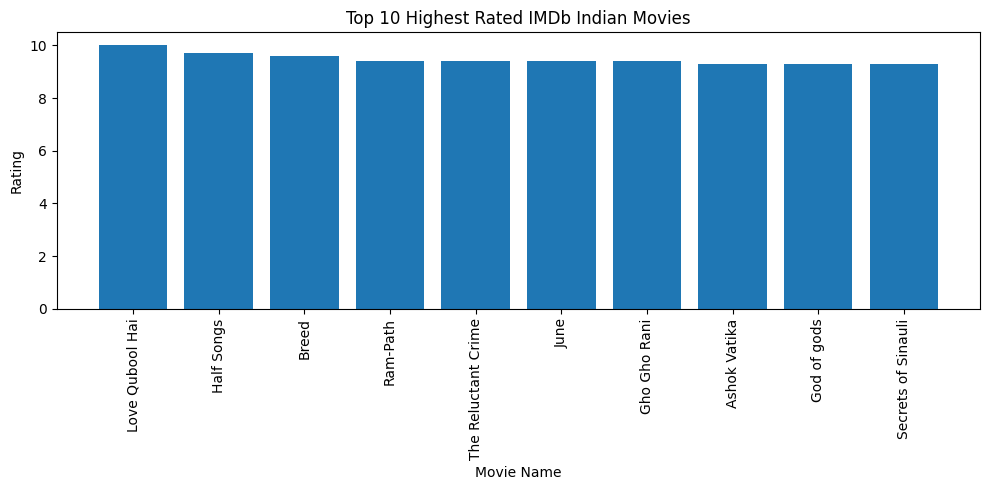


Top Genres:
Genre
Drama                   2780
Action                  1289
Thriller                 779
Romance                  708
Drama, Romance           524
Comedy                   495
Action, Crime, Drama     455
Drama, Family            418
Horror                   322
Action, Drama            316
Name: count, dtype: int64


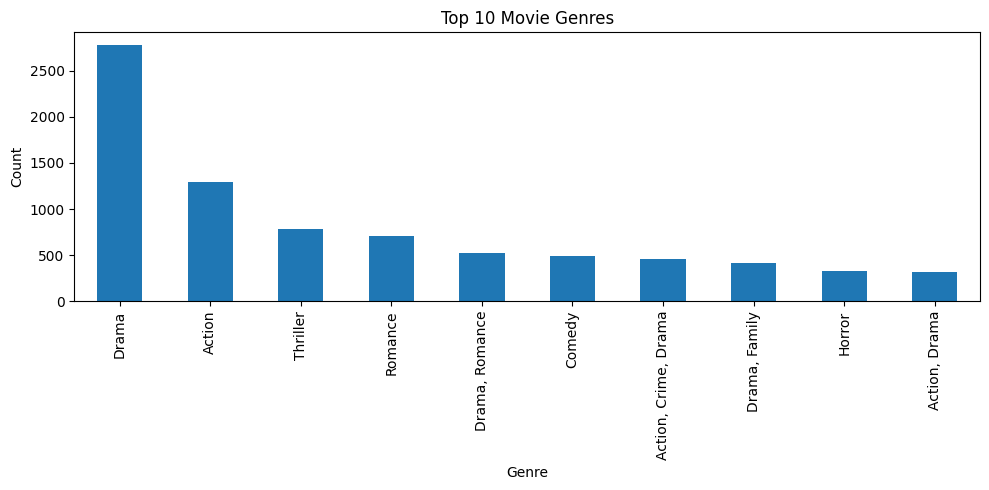


Cleaned dataset saved successfully!


In [3]:
# ==========================================
# IMDb Movies India Dataset - Google Colab Code
# ==========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Upload Dataset in Colab - Already handled by previous cell
# from google.colab import files
# uploaded = files.upload()

# Step 3: Read CSV File - Already handled by previous cell
# Replace filename if needed
# df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# Step 4: Display First 5 Rows
print("First 5 Rows:")
print(df.head())

# Step 5: Dataset Information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

# Step 6: Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 7: Basic Statistics
print("\nStatistics:")
print(df.describe())

# Step 8: Clean Data

# Remove brackets from Year column
df['Year'] = df['Year'].str.extract('(\\d+)')

# Convert Year to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Remove 'min' from Duration
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)

# Convert Duration to numeric
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Votes column
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

print("\nCleaned Data:")
print(df.head())

# Step 9: Top 10 Highest Rated Movies
top_movies = df[['Name', 'Rating']].dropna().sort_values(by='Rating', ascending=False).head(10)

print("\nTop 10 Highest Rated Movies:")
print(top_movies)

# Step 10: Plot Top Rated Movies
plt.figure(figsize=(10,5))
plt.bar(top_movies['Name'], top_movies['Rating'])
plt.xticks(rotation=90)
plt.xlabel("Movie Name")
plt.ylabel("Rating")
plt.title("Top 10 Highest Rated IMDb Indian Movies")
plt.tight_layout()
plt.show()

# Step 11: Genre Count
genre_count = df['Genre'].value_counts().head(10)

print("\nTop Genres:")
print(genre_count)

# Step 12: Plot Genre Distribution
plt.figure(figsize=(10,5))
genre_count.plot(kind='bar')
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Top 10 Movie Genres")
plt.tight_layout()
plt.show()

# Step 13: Save Cleaned Dataset
df.to_csv('Cleaned_IMDb_Movies_India.csv', index=False)

print("\nCleaned dataset saved successfully!")

## Data Preprocessing and Feature Engineering for Modeling

Now that we have cleaned the numerical data, we need to handle the remaining missing values and convert categorical features into a format suitable for a regression model. We will focus on the 'Genre', 'Director', and 'Actor' columns.

In [4]:
# Drop rows where 'Rating' is NaN, as it's our target variable
df_model = df.dropna(subset=['Rating']).copy()

print(f"Shape after dropping rows with missing ratings: {df_model.shape}")

# Impute missing numerical columns with their median
for col in ['Year', 'Duration', 'Votes']:
    if df_model[col].isnull().any():
        median_val = df_model[col].median()
        df_model[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Impute missing categorical columns with 'Unknown'
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    if df_model[col].isnull().any():
        df_model[col].fillna('Unknown', inplace=True)
        print(f"Imputed missing values in '{col}' with 'Unknown'")

print("\nMissing values after imputation:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

print("\nFirst 5 rows of the DataFrame after handling missing values:")
display(df_model.head())

Shape after dropping rows with missing ratings: (7919, 10)
Imputed missing values in 'Duration' with median: 134.0
Imputed missing values in 'Genre' with 'Unknown'
Imputed missing values in 'Director' with 'Unknown'
Imputed missing values in 'Actor 1' with 'Unknown'
Imputed missing values in 'Actor 2' with 'Unknown'
Imputed missing values in 'Actor 3' with 'Unknown'

Missing values after imputation:
Series([], dtype: int64)

First 5 rows of the DataFrame after handling missing values:


/tmp/ipykernel_17695/259570154.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(median_val, inplace=True)
/tmp/ipykernel_17695/259570154.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


### Processing Multi-valued Categorical Features (Genre)

The 'Genre' column contains multiple genres for a single movie, separated by commas. To use this effectively as a feature, we need to one-hot encode each individual genre.

In [5]:
# Expand 'Genre' column to individual genres and one-hot encode
df_model['Genre'] = df_model['Genre'].apply(lambda x: str(x).split(', '))

genres_df = df_model['Genre'].explode()
genres_one_hot = pd.get_dummies(genres_df, prefix='Genre')

# Aggregate the one-hot encoded genres back to the movie level
genres_encoded = genres_one_hot.groupby(genres_one_hot.index).sum()

# Merge the one-hot encoded genres back to the main DataFrame
df_model = df_model.drop('Genre', axis=1)
df_model = df_model.merge(genres_encoded, left_index=True, right_index=True, how='left')

print("\nFirst 5 rows of the DataFrame after genre one-hot encoding:")
display(df_model.head())
print(f"Shape after genre one-hot encoding: {df_model.shape}")


First 5 rows of the DataFrame after genre one-hot encoding:


,Name,Year,Duration,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Action,...,Genre_Musical,Genre_Mystery,Genre_News,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_Unknown,Genre_War,Genre_Western
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,0,...,0,0,0,0,0,0,0,0,0,0
3,#Yaaram,2019.0,110.0,4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,0,...,0,0,0,1,0,0,0,0,0,0
5,...Aur Pyaar Ho Gaya,1997.0,147.0,4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,0,...,1,0,0,0,0,0,0,0,0,0
6,...Yahaan,2005.0,142.0,7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,0,...,0,0,0,1,0,0,0,0,1,0
8,?: A Question Mark,2012.0,82.0,5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,0,...,0,1,0,0,0,0,1,0,0,0


Shape after genre one-hot encoding: (7919, 32)


### One-hot Encoding Director and Actor Features

To incorporate the influence of 'Director' and 'Actor' on movie ratings, we will one-hot encode these columns. Given that there can be a large number of unique directors and actors, we will select the top N most frequent ones to keep the feature space manageable, and group the rest as 'Other'.

In [6]:
# Function to get top N categories and one-hot encode
def one_hot_encode_top_n(df, column, n_top=50):
    # Get value counts of the column
    value_counts = df[column].value_counts()
    # Get top N categories
    top_n_values = value_counts.head(n_top).index.tolist()

    # Create a new column indicating if a value is in top N
    df[f'{column}_processed'] = df[column].apply(lambda x: x if x in top_n_values else 'Other')

    # One-hot encode the processed column
    dummies = pd.get_dummies(df[f'{column}_processed'], prefix=column)

    # Drop the original and temporary processed column
    df = df.drop(columns=[column, f'{column}_processed'])

    # Concatenate the new dummy variables
    df = pd.concat([df, dummies], axis=1)
    return df

# One-hot encode 'Director' (top 100 directors)
# A higher number is chosen for director as they have a significant impact
df_model = one_hot_encode_top_n(df_model, 'Director', n_top=100)
print(f"Shape after Director one-hot encoding: {df_model.shape}")

# One-hot encode 'Actor 1', 'Actor 2', 'Actor 3' (top 50 for each)
# We'll treat each actor column separately as their position might imply different impact
df_model = one_hot_encode_top_n(df_model, 'Actor 1', n_top=50)
print(f"Shape after Actor 1 one-hot encoding: {df_model.shape}")

df_model = one_hot_encode_top_n(df_model, 'Actor 2', n_top=50)
print(f"Shape after Actor 2 one-hot encoding: {df_model.shape}")

df_model = one_hot_encode_top_n(df_model, 'Actor 3', n_top=50)
print(f"Shape after Actor 3 one-hot encoding: {df_model.shape}")

print("\nFinal DataFrame head after all feature engineering:")
display(df_model.head())

Shape after Director one-hot encoding: (7919, 132)
Shape after Actor 1 one-hot encoding: (7919, 182)
Shape after Actor 2 one-hot encoding: (7919, 232)
Shape after Actor 3 one-hot encoding: (7919, 282)

Final DataFrame head after all feature engineering:


,Name,Year,Duration,Rating,Votes,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,...,Actor 3_Sanjay Dutt,Actor 3_Shabana Azmi,Actor 3_Shakti Kapoor,Actor 3_Shashikala,Actor 3_Shatrughan Sinha,Actor 3_Sridevi,Actor 3_Sujit Kumar,Actor 3_Unknown,Actor 3_Vinod Khanna,Actor 3_Vinod Mehra
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,7.0,8.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,#Yaaram,2019.0,110.0,4.4,35.0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
5,...Aur Pyaar Ho Gaya,1997.0,147.0,4.7,827.0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
6,...Yahaan,2005.0,142.0,7.4,1086.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
8,?: A Question Mark,2012.0,82.0,5.6,326.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Model Training and Evaluation

With our data now fully preprocessed and features engineered, we can proceed to train a regression model. We will use a `RandomForestRegressor` as it generally performs well on datasets with mixed data types and can capture non-linear relationships.

X_train shape: (6335, 280)
X_test shape: (1584, 280)
y_train shape: (6335,)
y_test shape: (1584,)

Training Random Forest Regressor...
Random Forest Regressor training complete.

Random Forest - Mean Squared Error (MSE): 1.1833
Random Forest - R-squared (R2): 0.3635


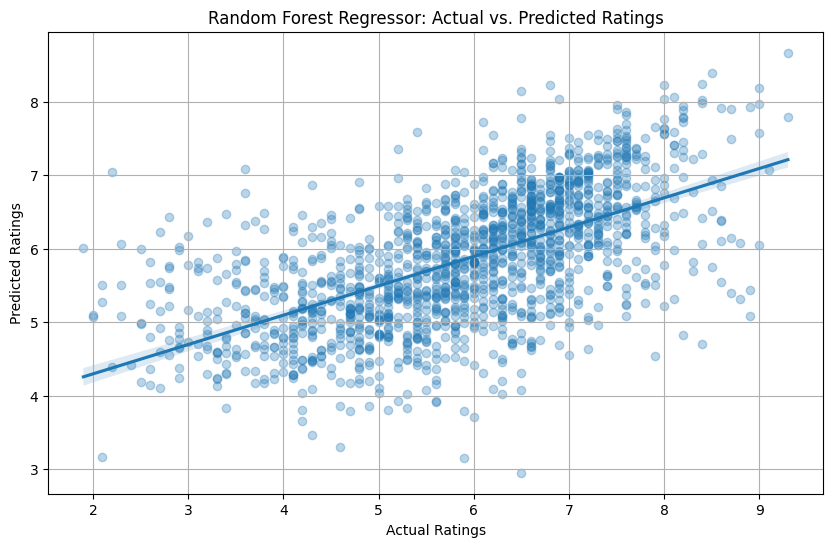

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the 'Name' column as it's an identifier and not a feature for the model
X = df_model.drop(columns=['Name', 'Rating'])
y = df_model['Rating']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Random Forest Regressor model
# Using n_estimators=100 as a starting point; this can be tuned later.
# random_state for reproducibility.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("\nTraining Random Forest Regressor...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor training complete.")

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"\nRandom Forest - Mean Squared Error (MSE): {rf_mse:.4f}")
print(f"Random Forest - R-squared (R2): {rf_r2:.4f}")

# Visualize Predictions vs Actuals
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=rf_y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest Regressor: Actual vs. Predicted Ratings")
plt.grid(True)
plt.show()

## Hyperparameter Tuning for Random Forest Regressor

To further improve the model's performance, we will perform hyperparameter tuning using `GridSearchCV`. This will help us find the best combination of parameters for our `RandomForestRegressor`.


Starting GridSearchCV for Random Forest Regressor...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV complete.

Best Parameters found: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Mean Squared Error (from cross-validation): 1.2410

Best Random Forest - Mean Squared Error (on test set): 1.1596
Best Random Forest - R-squared (on test set): 0.3763


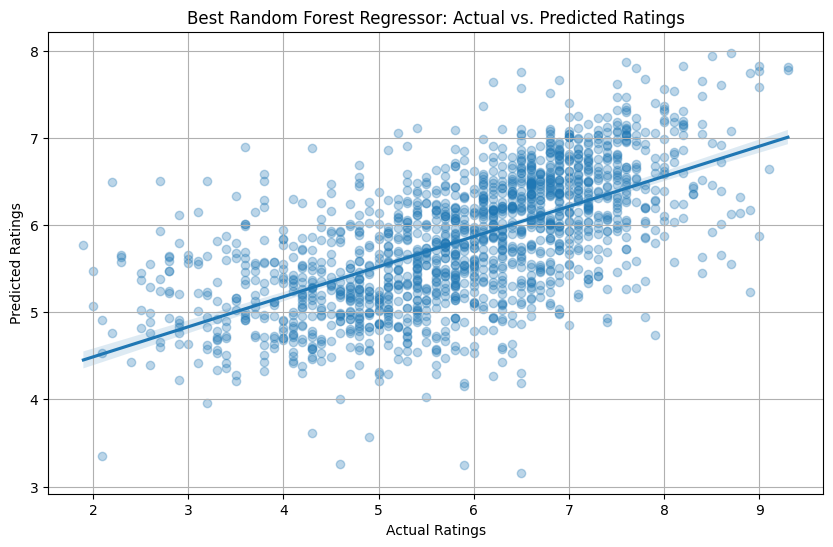

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # The minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# n_jobs=-1 uses all available processors
# cv=3 for 3-fold cross-validation
# verbose=2 to see the progress
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error' # Optimize for lower MSE
)

print("\nStarting GridSearchCV for Random Forest Regressor...")
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_ # Convert back to positive MSE

print(f"\nBest Parameters found: {best_params}")
print(f"Best Mean Squared Error (from cross-validation): {best_score:.4f}")

# Get the best estimator (the model with the best parameters)
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
best_rf_y_pred = best_rf_model.predict(X_test)

# Evaluate the best model
best_rf_mse = mean_squared_error(y_test, best_rf_y_pred)
best_rf_r2 = r2_score(y_test, best_rf_y_pred)

print(f"\nBest Random Forest - Mean Squared Error (on test set): {best_rf_mse:.4f}")
print(f"Best Random Forest - R-squared (on test set): {best_rf_r2:.4f}")

# Visualize Predictions vs Actuals for the best model
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=best_rf_y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Best Random Forest Regressor: Actual vs. Predicted Ratings")
plt.grid(True)
plt.show()

## Feature Importance Analysis

To understand which features are most influential in predicting movie ratings, we will extract and visualize the feature importances from our best Random Forest Regressor model.


Top 20 Most Important Features:


,Feature,Importance
0,Year,0.211818
2,Votes,0.196690
1,Duration,0.117763
3,Genre_Action,0.027324
14,Genre_Horror,0.024183
10,Genre_Drama,0.023462
9,Genre_Documentary,0.022524
19,Genre_Romance,0.018195
7,Genre_Comedy,0.015771
8,Genre_Crime,0.012492


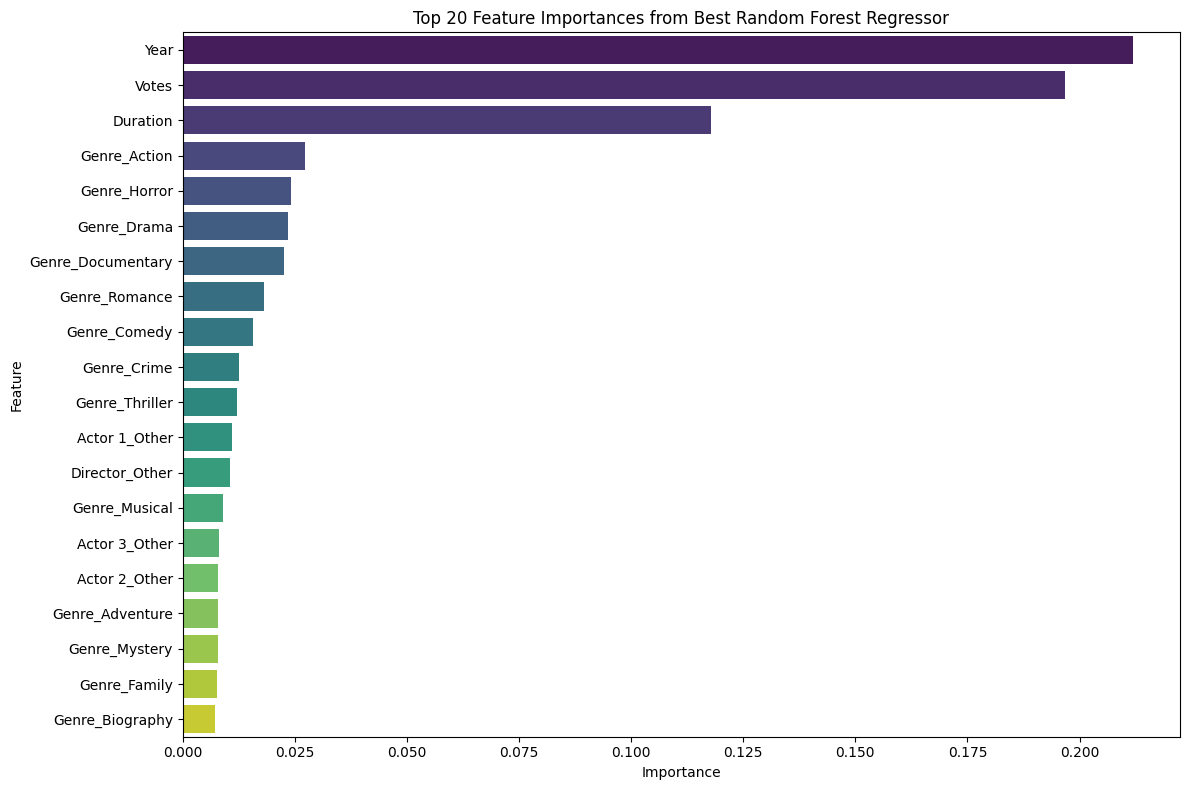

In [10]:
# Get feature importances from the best model
feature_importances = best_rf_model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Features:")
display(features_df.head(20))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances from Best Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Experimenting with Gradient Boosting Regressor (LightGBM)

Given the moderate performance of the Random Forest model, we will now explore a Gradient Boosting Regressor using the LightGBM library. Gradient Boosting models often provide higher accuracy by building trees sequentially, with each new tree correcting errors made by previous ones.


Training LightGBM Regressor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 6335, number of used features: 161
[LightGBM] [Info] Start training from score 5.831018
LightGBM Regressor training complete.

LightGBM - Mean Squared Error (MSE): 1.1001
LightGBM - R-squared (R2): 0.4083


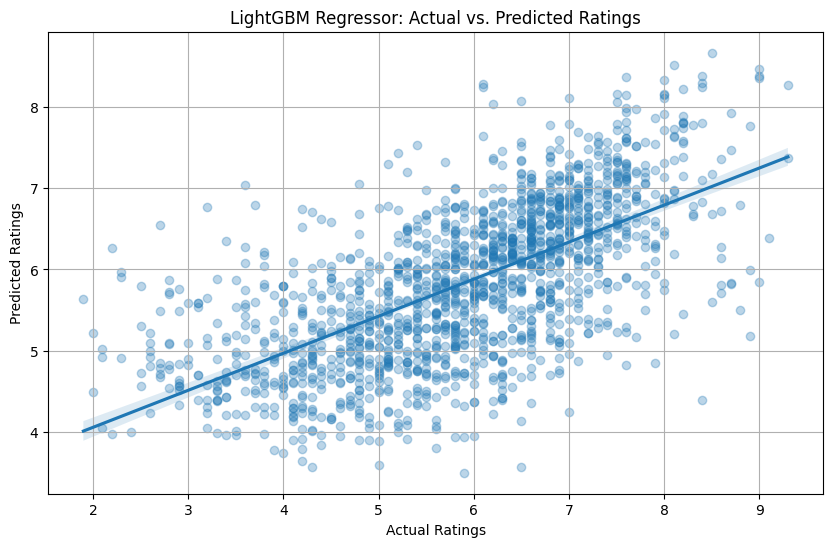

In [11]:
# Install LightGBM if not already installed
# !pip install lightgbm

import lightgbm as lgb

print("\nTraining LightGBM Regressor...")

# Initialize and train the LightGBM Regressor model
# Using some default parameters; these can be tuned later.
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=500,  # Number of boosting rounds
    learning_rate=0.05, # Step size shrinkage to prevent overfitting
    num_leaves=31,     # Max number of leaves in one tree
    max_depth=-1,      # No limit on tree depth
    random_state=42,   # For reproducibility
    n_jobs=-1          # Use all available cores
)

lgbm_model.fit(X_train, y_train)
print("LightGBM Regressor training complete.")

# Make predictions on the test set
lgbm_y_pred = lgbm_model.predict(X_test)

# Evaluate the LightGBM model
lgbm_mse = mean_squared_error(y_test, lgbm_y_pred)
lgbm_r2 = r2_score(y_test, lgbm_y_pred)

print(f"\nLightGBM - Mean Squared Error (MSE): {lgbm_mse:.4f}")
print(f"LightGBM - R-squared (R2): {lgbm_r2:.4f}")

# Visualize Predictions vs Actuals for LightGBM
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=lgbm_y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("LightGBM Regressor: Actual vs. Predicted Ratings")
plt.grid(True)
plt.show()

## Hyperparameter Tuning for LightGBM Regressor

To further optimize the LightGBM model, we will perform hyperparameter tuning using `GridSearchCV`. This helps in finding the best combination of parameters that yields the highest performance.


Starting simplified GridSearchCV for LightGBM Regressor...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 6335, number of used features: 161
[LightGBM] [Info] Start training from score 5.831018
GridSearchCV for LightGBM complete.

Best Parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
Best LightGBM - MSE: 1.0843
Best LightGBM - R-squared: 0.4168


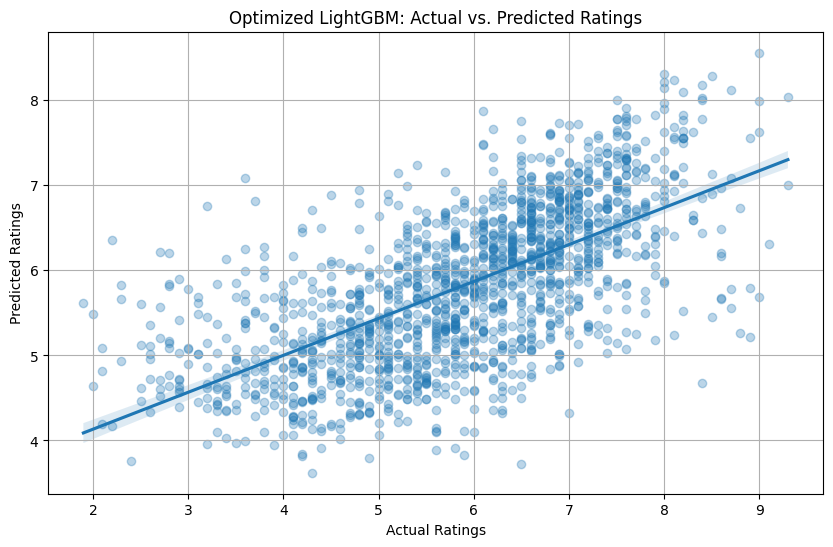

In [13]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# Simplified parameter grid to ensure completion
param_grid_lgbm = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31],
    'max_depth': [-1]
}

# Initialize GridSearchCV for LightGBM
grid_search_lgbm = GridSearchCV(
    estimator=lgb.LGBMRegressor(objective='regression', metric='rmse', random_state=42, n_jobs=-1),
    param_grid=param_grid_lgbm,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_squared_error'
)

print("\nStarting simplified GridSearchCV for LightGBM Regressor...")
grid_search_lgbm.fit(X_train, y_train)
print("GridSearchCV for LightGBM complete.")

# Results
best_params_lgbm = grid_search_lgbm.best_params_
best_lgbm_model = grid_search_lgbm.best_estimator_
best_lgbm_y_pred = best_lgbm_model.predict(X_test)

best_lgbm_mse = mean_squared_error(y_test, best_lgbm_y_pred)
best_lgbm_r2 = r2_score(y_test, best_lgbm_y_pred)

print(f"\nBest Parameters: {best_params_lgbm}")
print(f"Best LightGBM - MSE: {best_lgbm_mse:.4f}")
print(f"Best LightGBM - R-squared: {best_lgbm_r2:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=best_lgbm_y_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Optimized LightGBM: Actual vs. Predicted Ratings')
plt.grid(True)
plt.show()

In [2]:
# Extract the zip file
import zipfile
import os

zip_file_name = 'archive (1).zip'
extract_path = 'IMDb_Movies_India_Dataset'

if not os.path.exists(extract_path):
    print(f"Extracting {zip_file_name}...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print(f"Dataset already extracted to {extract_path}.")

# Update the DataFrame reading to point to the extracted file
df = pd.read_csv(os.path.join(extract_path, 'IMDb Movies India.csv'), encoding='latin1')

Extracting archive (1).zip...
Extraction complete.
